---

# Top 7 Loss Functions to Evaluate Regression Models

---

## Learning Objectives

* Understand different loss functions in Machine Learning.
* Know the difference between loss function and cost function.
* Learn how to implement different loss functions in Python.

---

## What Are Loss Functions?

Loss functions, also known as objective functions, are pivotal in machine learning algorithms. They guide decision-making by mapping choices to associated costs. Imagine being atop a hill and needing to descend. Rejecting uphill paths, you’d opt for the steepest downhill slope. Similarly, a loss function aids in minimizing errors during training by quantifying the discrepancy between predicted and actual values. This optimization process aims to achieve an optimum, where the loss function yields the lowest possible value. Common loss functions include quadratic loss (e.g., Mean Squared Error) and absolute value (e.g., Mean Absolute Error). Understanding and leveraging loss functions enhance comprehension of machine learning algorithms.

---

## What Are Regression Loss Functions?

You must be quite familiar with linear regression at this point. It deals with modeling a linear relationship between a dependent variable, Y, and several independent variables, X_i’s. Thus, we essentially fit a line in space on these variables.

---

## Steps for Loss Functions

* Define the predictor function f(X), and identify the parameters to find.
* Determine the loss for each training example.
* Derive the expression for the Cost Function, representing the average loss across all examples.
* Compute the gradient of the Cost Function concerning each unknown parameter.
* Select the learning rate and execute the weight update rule for a fixed number of iterations.

---

find the gradient for gradient descent

---

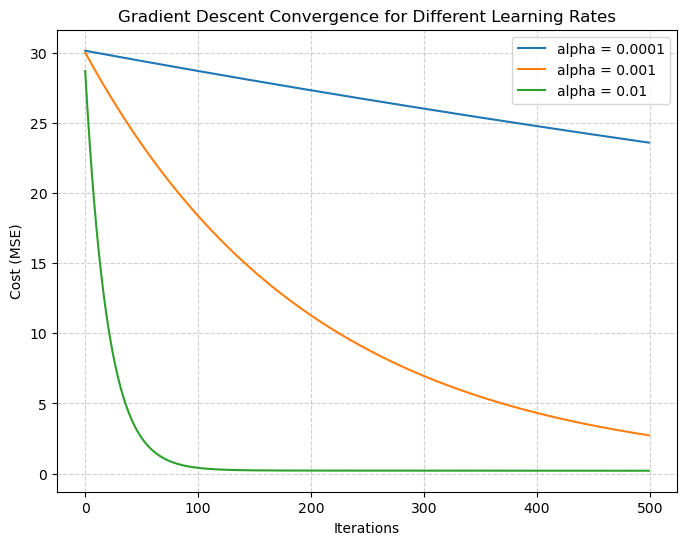

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dummy Boston Data (Agar aapke paas asli data hai to use load karlein)
# Hum yahan test karne ke liye random data bana rahe hain
np.random.seed(42)
X = np.random.rand(100)
Y = 4 + 3 * X + np.random.randn(100) * 0.5  # True m=3, b=4 aur thoda noise

# --- Aapka Diya Hua Function (Thodi si modification ke sath taake calculations sahi hon) ---
def update_weights_MSE(m, b, X, Y, learning_rate):
    m_deriv = 0
    b_deriv = 0
    N = len(X)
    for i in range(N):
        # Partial derivatives
        m_deriv += -2 * X[i] * (Y[i] - (m * X[i] + b))
        b_deriv += -2 * (Y[i] - (m * X[i] + b))

    # Average derivatives aur weights update
    m -= (m_deriv / float(N)) * learning_rate
    b -= (b_deriv / float(N)) * learning_rate

    return m, b

# 2. MSE (Cost) Calculate karne ka function
def compute_cost(m, b, X, Y):
    N = len(X)
    total_error = 0
    for i in range(N):
        total_error += (Y[i] - (m * X[i] + b)) ** 2
    return total_error / float(N)

# 3. Main Experiment Loop
# Alag-alag learning rates (Alpha values)
learning_rates = [0.0001, 0.001, 0.01]
iterations = 500

# Graph plotting shuru karne ke liye figure setup
plt.figure(figsize=(8, 6))

# Har learning rate ke liye model ko train karenge
for alpha in learning_rates:
    # Har baar weights ko shuruati values (jaise m=0, b=0) par reset karenge
    m, b = 0.0, 0.0
    cost_history = []  # Har iteration ka cost save karne ke liye list
    
    for epoch in range(iterations):
        # Weights update karein
        m, b = update_weights_MSE(m, b, X, Y, alpha)
        # Naya cost nikaal kar list mein daalein
        cost = compute_cost(m, b, X, Y)
        cost_history.append(cost)
    
    # Is specific alpha ka curve graph par plot karein
    plt.plot(range(iterations), cost_history, label=f'alpha = {alpha}')

# 4. Graph ki Formatting (Labels aur Styling)
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence for Different Learning Rates')
plt.legend()  # Alag-alag rangon ke labels dikhane ke liye
plt.grid(True, linestyle='--', alpha=0.6)

# Graph ko screen par show karein
plt.show()

---
## Hinge Loss

Hinge loss is primarily used with Support Vector Machine (SVM) Classifiers with class labels -1 and 1. So make sure you change the label of the ‘Malignant’ class in the dataset from 0 to -1.

---

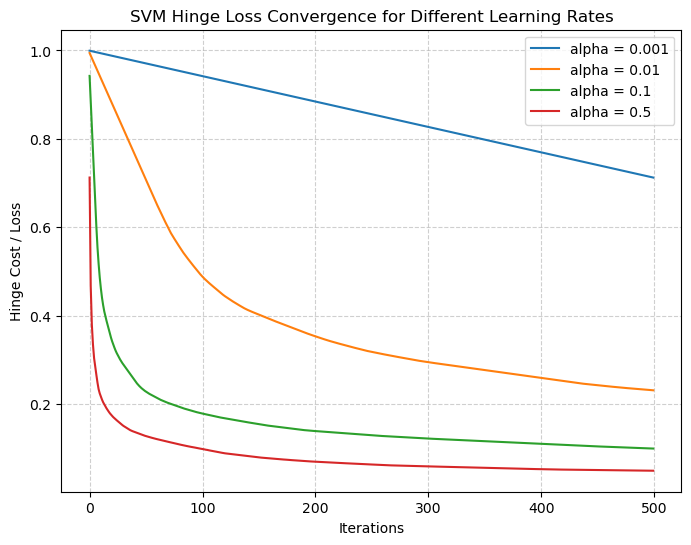

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dummy Classification Data Generate Karna (SVM ke liye)
np.random.seed(42)
num_samples = 100

# Do features generate kar rahe hain (X1 aur X2)
X1 = np.random.randn(num_samples)
X2 = np.random.randn(num_samples)

# Targets (Y) ko +1 ya -1 hona chahiye Hinge Loss ke liye
# Ek simple linear boundary (X1 + X2 > 0) ke mutabiq labels de rahe hain
Y = np.where(X1 + X2 > 0.5, 1, -1)


# --- Aapka Diya Hua Hinge Loss Update Function ---
def update_weights_Hinge(m1, m2, b, X1, X2, Y, learning_rate):    
    m1_deriv = 0    
    m2_deriv = 0    
    b_deriv = 0    
    N = len(X1)    
    for i in range(N):        
        # Calculate partial derivatives        
        if Y[i] * (m1 * X1[i] + m2 * X2[i] + b) <= 1:          
            m1_deriv += -X1[i] * Y[i]          
            m2_deriv += -X2[i] * Y[i]          
            b_deriv += -Y[i]        
        # else derivatives are zero    
        
    # Weights aur bias update
    m1 -= (m1_deriv / float(N)) * learning_rate    
    m2 -= (m2_deriv / float(N)) * learning_rate    
    b -= (b_deriv / float(N)) * learning_rate    
    return m1, m2, b


# 2. Total Hinge Cost Calculate karne ka function
def compute_hinge_cost(m1, m2, b, X1, X2, Y):
    N = len(X1)
    total_loss = 0
    for i in range(N):
        # Hinge Loss formula: max(0, 1 - Y * (m1*X1 + m2*X2 + b))
        distance = 1 - Y[i] * (m1 * X1[i] + m2 * X2[i] + b)
        total_loss += max(0, distance)
    return total_loss / float(N)


# 3. Main Experiment Loop (Multiple Learning Rates ke liye)
learning_rates = [0.001, 0.01, 0.1, 0.5]
iterations = 500

plt.figure(figsize=(8, 6))

# Har learning rate par model ko check karenge
for alpha in learning_rates:
    # Har dafa parameters ko zero se shuru karenge
    m1, m2, b = 0.0, 0.0, 0.0
    cost_history = []
    
    for epoch in range(iterations):
        # Weights update karein
        m1, m2, b = update_weights_Hinge(m1, m2, b, X1, X2, Y, alpha)
        # Naya cost nikaal kar list mein daalein
        cost = compute_hinge_cost(m1, m2, b, X1, X2, Y)
        cost_history.append(cost)
        
    # Is specific alpha ka cost curve plot karein
    plt.plot(range(iterations), cost_history, label=f'alpha = {alpha}')

# 4. Graph ki Styling
plt.xlabel('Iterations')
plt.ylabel('Hinge Cost / Loss')
plt.title('SVM Hinge Loss Convergence for Different Learning Rates')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Graph show karein
plt.show()

---

## Multi-Class Cross Entropy Loss
The multi-class cross-entropy loss function is a generalization of the Binary Cross Entropy loss. The loss for input vector X_i and the corresponding one-hot encoded target vector Y_i

---

Training model with learning rate (alpha): 0.001...
Training model with learning rate (alpha): 0.01...
Training model with learning rate (alpha): 0.1...


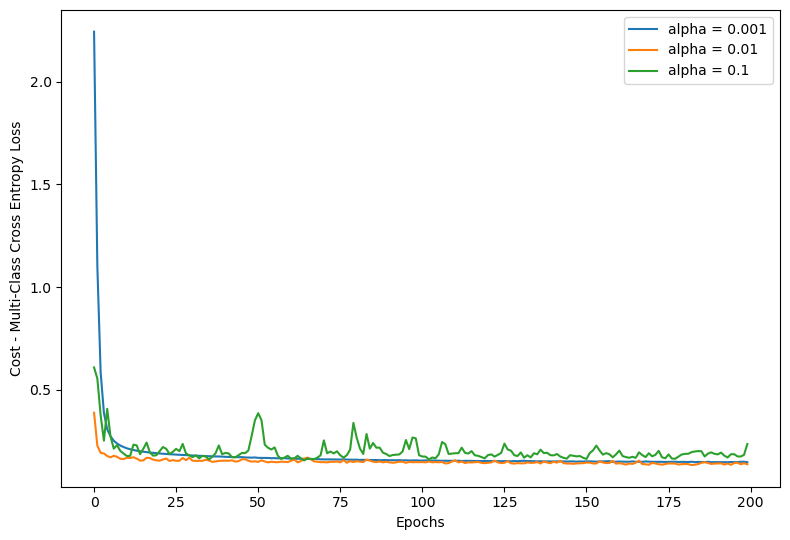

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import os
import warnings

# Warnings ko chupane ke liye
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# 1. DATA KO MUSHKIL BANANA 
# cluster_std=3.5 karne se data points aapas mein mix ho jayenge, jisse loss dheere dheere kam hoga
dataX, y = make_blobs(n_samples=600, centers=3, n_features=2, cluster_std=3.5, random_state=42)
dummy_Y = to_categorical(y)

learning_rates = [0.001, 0.01, 0.1]
histories = {}

# 2. Models Training Loop
for alpha in learning_rates:
    print(f"Training model with learning rate (alpha): {alpha}...")
    
    model = Sequential()
    model.add(Input(shape=(2,))) # Naya tareeqa warning se bachne ke liye
    model.add(Dense(50, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    opt = Adam(learning_rate=alpha)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    
    # Validation data ko hataya taake training smoothly curves dikhaye
    history = model.fit(dataX, dummy_Y, epochs=200, verbose=0)
    histories[alpha] = history

# 3. Plotting 
plt.figure(figsize=(8, 5.5))

for alpha in learning_rates:
    # Loss curves ko plot karna
    plt.plot(histories[alpha].history['loss'], label=f'alpha = {alpha}')

plt.xlabel('Epochs')
plt.ylabel('Cost - Multi-Class Cross Entropy Loss')
plt.legend(loc='upper right')
plt.grid(False)

plt.tight_layout()
plt.show()

---

## KL-Divergence
The Kullback-Liebler Divergence is a measure of how a probability distribution differs from another distribution. A KL-divergence of zero indicates that the distributions are identical.

---

Training model with learning rate (alpha): 0.001...
Training model with learning rate (alpha): 0.01...
Training model with learning rate (alpha): 0.1...


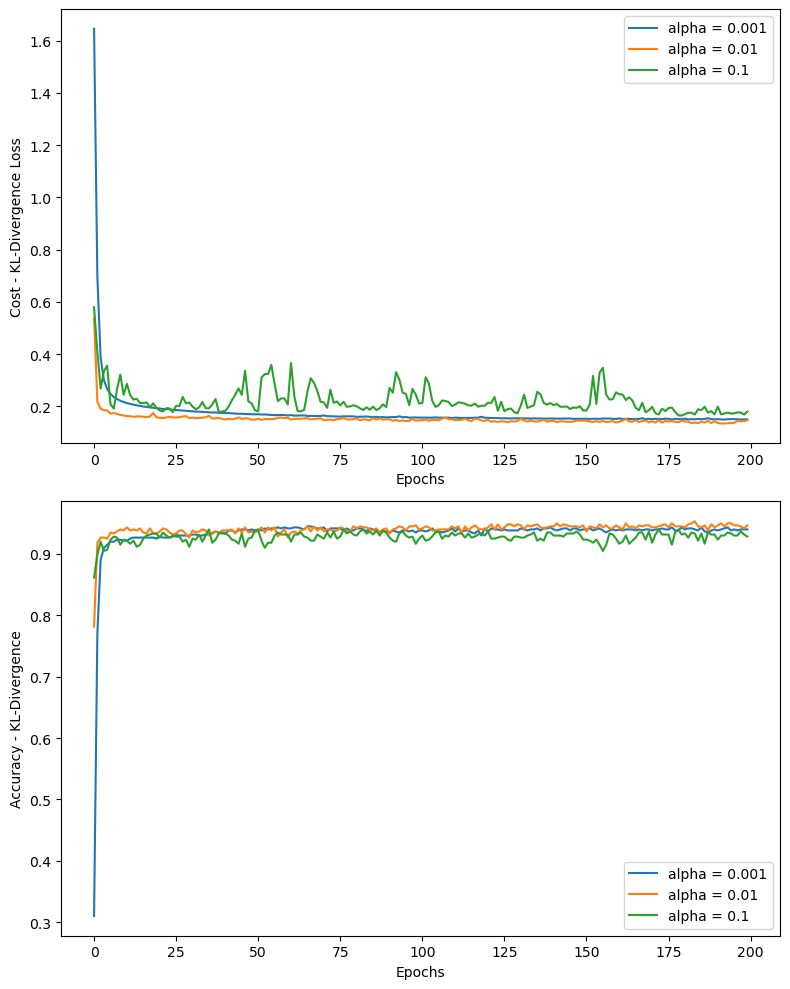

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import os
import warnings

# Warnings ko chupane ke liye
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# 1. Multi-Class Data Generate aur Prepare karna
dataX, y = make_blobs(n_samples=600, centers=3, n_features=2, cluster_std=3.5, random_state=42)
dummy_Y = to_categorical(y)

learning_rates = [0.001, 0.01, 0.1]
histories = {}

# 2. Models Training Loop
for alpha in learning_rates:
    print(f"Training model with learning rate (alpha): {alpha}...")
    
    model = Sequential()
    model.add(Input(shape=(2,))) 
    model.add(Dense(50, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    opt = Adam(learning_rate=alpha)
    
    model.compile(loss='kl_divergence', optimizer=opt, metrics=['accuracy'])
    
    history = model.fit(dataX, dummy_Y, epochs=200, verbose=0)
    histories[alpha] = history

# 3. Plots Setup (Dono Cost aur Accuracy graphs ek ke neeche ek)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

for alpha in learning_rates:
    # Top Plot: Loss Curve
    ax1.plot(histories[alpha].history['loss'], label=f'alpha = {alpha}')
    
    # Bottom Plot: Accuracy Curve
    ax2.plot(histories[alpha].history['accuracy'], label=f'alpha = {alpha}')

# --- Top Graph (KL-Divergence Loss) ki Formatting ---
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Cost - KL-Divergence Loss')
ax1.legend(loc='upper right')
ax1.grid(False)

# --- Bottom Graph (Accuracy) ki Formatting ---
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy - KL-Divergence')
ax2.legend(loc='lower right')
ax2.grid(False)

plt.tight_layout()
plt.show()